<a href="https://colab.research.google.com/github/Rafanellli/yolov8-mineral-classification/blob/main/mineral_code_fix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive') #kita hubungin dlu Collab sama Drive kita


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
%cd '/content/drive/My Drive/Kelas online seraf/Geosoftware/Kelas klasifikasi mineral/Dataset/Dataset'
#Kita assign google colllab ke folder di drive kita yg kita pengen

/content/drive/My Drive/Kelas online seraf/Geosoftware/Kelas klasifikasi mineral/Dataset/Dataset


In [3]:
ls #untuk ngecheck isi foldernya ada apa aja

biotite/  chrysocolla/  muscovite/  quartz/  testtrainval/
bornite/  malachite/    pyrite/     runs/    yolov8n-cls.pt


In [4]:
import os

base_dir = '/content/drive/My Drive/Kelas online seraf/Geosoftware/Kelas klasifikasi mineral/Dataset/Dataset/testtrainval/'

#membuat folder train, val, dan test
os.makedirs(base_dir + '/train', exist_ok=True)
os.makedirs(base_dir + '/val', exist_ok=True)
os.makedirs(base_dir + '/test', exist_ok=True)

#Kita list dlu kategori mineralnya apa aja
categories = ['quartz', 'pyrite', 'muscovite', 'malachite', 'chrysocolla', 'bornite', 'biotite' ]

#membuat subfolder untuk setiap kategori
for category in categories:
  os.makedirs(base_dir + '/train/' + category, exist_ok=True)
  os.makedirs(base_dir + '/val/' + category, exist_ok=True)
  os.makedirs(base_dir + '/test/' + category, exist_ok=True)

Kode di atas kita pake untuk isi folder testtrainval. Nanti di dalem folder itu akan diisi sama folder train, val, sama test

In [5]:
#kodingan di bawah ini tempat di mana data kita masih dalam folder rapih. Setiap foldernya berisi foto foto mineral, tapi belum dipecah jadi train, test, val.
mineral_dir = '/content/drive/My Drive/Kelas online seraf/Geosoftware/Kelas klasifikasi mineral/Dataset/Dataset/'

#**Ngebagi test train val data**

Nah, proses di bawah ini kita lakuin untuk pecah folder folder rapih di atas yang berisi mineral, jadi kebagi train, test, dan val

In [6]:
import os
import shutil
import random

# bikin fungsi ngebagi data
def split_data(category, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15):
  category_path = os.path.join(mineral_dir, category)
  files = os.listdir(category_path)
  random.shuffle(files)

  # trus itung deh pembagian datanya
  train_count = int(len(files) * train_ratio)
  val_count = int(len(files) * val_ratio)
  test_count = int(len(files) * test_ratio)

  # TAMBAHAN: Bikin foldernya otomatis di sini biar gak FileNotFoundError trus wkwkwwwkk capee diriku
  os.makedirs(os.path.join(base_dir, 'train', category), exist_ok=True)
  os.makedirs(os.path.join(base_dir, 'val', category), exist_ok=True)
  os.makedirs(os.path.join(base_dir, 'test', category), exist_ok=True)

  # copy file ke folder train, val, dan test
  for i, file in enumerate(files):
    if i < train_count:
      shutil.copy(os.path.join(category_path, file), os.path.join(base_dir, 'train', category, file))
    elif i < train_count + val_count:
      shutil.copy(os.path.join(category_path, file), os.path.join(base_dir, 'val', category, file))
    else:
      shutil.copy(os.path.join(category_path, file), os.path.join(base_dir, 'test', category, file))

# membagi data untuk setiap kategori
for category in categories:
  split_data(category)

print('pembagian data selesai gengs!')

pembagian data selesai gengs!


In [7]:
!pip install ultralytics

from ultralytics import YOLO

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [8]:
model = YOLO('yolov8n-cls.pt')

In [9]:
results = model.train(data='/content/drive/My Drive/Kelas online seraf/Geosoftware/Kelas klasifikasi mineral/Dataset/Dataset/testtrainval/', epochs=3)

Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/My Drive/Kelas online seraf/Geosoftware/Kelas klasifikasi mineral/Dataset/Dataset/testtrainval/, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, n

# Evaluasi Model

In [11]:
from ultralytics import YOLO

# Memuat model yang telah dilatih (gunakan path ke model terbaik kita)
#Jadi di proses sebelumnya, kita udah ngetrain modelnya pada dataset di dalam folder train. Nah hasil modelnya itu ada dua, last.pt sama best.pt.
#pt. di sini maksudnya pytorch ya. Kita pake pytorch di sini
#
model = YOLO('/content/drive/My Drive/Kelas online seraf/Geosoftware/Kelas klasifikasi mineral/Dataset/Dataset/runs/classify/train-2/weights/best.pt')  # ganti dengan path ke model yang telah dilatih


In [13]:
#Oke di sini kita sekarang nge-eval model kita pake data yang udah di folder val yang udah kita siapin di atas
# Evaluasi model pada dataset validasi
# Di sini kita nyari folder val yang udah diriku ini siapkan di folder testtrainval
results_model = model.val(data='/content/drive/My Drive/Kelas online seraf/Geosoftware/Kelas klasifikasi mineral/Dataset/Dataset/testtrainval')


Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
train: /content/drive/My Drive/Kelas online seraf/Geosoftware/Kelas klasifikasi mineral/Dataset/Dataset/testtrainval/train... found 662 images in 7 classes ✅ 
val: /content/drive/My Drive/Kelas online seraf/Geosoftware/Kelas klasifikasi mineral/Dataset/Dataset/testtrainval/val... found 140 images in 7 classes ✅ 
test: /content/drive/My Drive/Kelas online seraf/Geosoftware/Kelas klasifikasi mineral/Dataset/Dataset/testtrainval/test... found 150 images in 7 classes ✅ 
val: Fast image access ✅ (ping: 1.0±0.3 ms, read: 43.3±30.4 MB/s, size: 149.4 KB)
val: Scanning /content/drive/My Drive/Kelas online seraf/Geosoftware/Kelas klasifikasi mineral/Dataset/Dataset/testtrainval/val... 140 images, 0 corrupt: 100% ━━━━━━━━━━━━ 140/140 24.5Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 9/9 1.0it/s 8.9s
                   all      0.821      0.993
Speed: 0.0ms preprocess, 16.3ms inference,

In [14]:
print(results_model)

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79fa5bd52030>
curves: []
curves_results: []
fitness: 0.9071428775787354
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.8214285969734192, 'metrics/accuracy_top5': 0.9928571581840515, 'fitness': 0.9071428775787354}
save_dir: PosixPath('/content/drive/MyDrive/Kelas online seraf/Geosoftware/Kelas klasifikasi mineral/Dataset/Dataset/runs/classify/val-2')
speed: {'preprocess': 0.0031022214248618445, 'inference': 16.313581828567944, 'loss': 0.00013184285307943355, 'postprocess': 0.00048242858221263826}
top1: 0.8214285969734192
top5: 0.9928571581840515


In [15]:
# Melakukan input gambar
results = model.predict('/content/drive/My Drive/Kelas online seraf/Geosoftware/Kelas klasifikasi mineral/Dataset/Dataset/testtrainval/test/bornite/0167.jpg')  # ganti dengan path gambar yang ingin Anda prediksi

# Menampilkan hasil prediksi
print(results)




image 1/1 /content/drive/My Drive/Kelas online seraf/Geosoftware/Kelas klasifikasi mineral/Dataset/Dataset/testtrainval/test/bornite/0167.jpg: 224x224 bornite 0.57, biotite 0.20, pyrite 0.09, muscovite 0.08, quartz 0.03, 23.4ms
Speed: 10.6ms preprocess, 23.4ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)
[ultralytics.engine.results.Results object with attributes:

boxes: None
keypoints: None
masks: None
names: {0: 'biotite', 1: 'bornite', 2: 'chrysocolla', 3: 'malachite', 4: 'muscovite', 5: 'pyrite', 6: 'quartz'}
obb: None
orig_img: array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
  

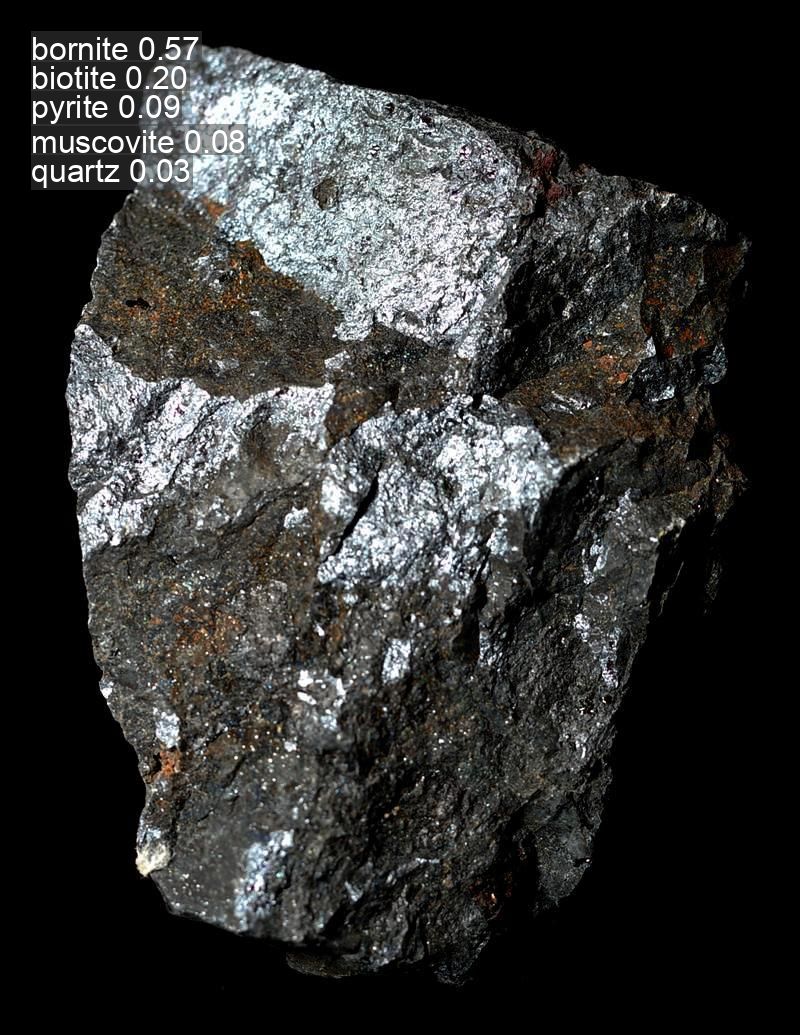

In [16]:
# Mengakses hasil prediksi pada gambar pertama dalam list
result_real = results[0]

# Menampilkan gambar dengan label hasil prediksi
result_real.show()  # Menampilkan gambar dengan label dan confidence

Kita tadi test pake gambar bornite, dan model kita berhasil nebak kalo ini beneran gambar bornite dengan peluang yang paling tinggi

Bedanya val sama test di sini adalah. Val di sini ikut dijadiin parameter untuk ngevalidasi hasil train kita. Makanya ada data val los tadi. Jadi val tuh bisa kita anggap kaya try out gitu. The real ujiannya ya di folder test ini